# 04 — Consensus vs Individual

Notebook 03 established inter-judge agreement. Now we drill into **divergence**:
how much does each judge deviate from the **ensemble consensus** (mean of all three
judges per instance and metric)?

## What we are looking for

| Failure mode | Description |
|---|---|
| **Score inflation** | Judge consistently scores higher than ensemble (optimism bias) |
| **Score deflation** | Judge consistently scores lower (pessimism bias) |
| **Random noise** | High per-instance variance without consistent direction |
| **Metric blindspot** | One metric systematically worse than others for a given judge |


In [1]:
# Setup: path, imports, and data-loading helper
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.agreement.bias import systematic_bias, bias_table, ensemble_scores

METRICS = ["context_relevance", "groundedness", "answer_relevance"]


def load_all_scores(root: Path) -> dict:
    """Load judge scores from data/eval/scores_*.json and inject ensemble."""
    result = {}
    eval_dir = root / "data" / "eval"
    for path in sorted(eval_dir.glob("scores_*.json")):
        records = json.loads(path.read_text())
        if not records:
            continue
        df = pd.DataFrame(records)
        if df["score"].isna().all():
            continue
        model = df["model"].iloc[0]
        instance_ids = df[df["metric"] == METRICS[0]].sort_values("id")["id"].tolist()
        model_scores = {}
        for metric in METRICS:
            sub = df[df["metric"] == metric].sort_values("id")
            model_scores[metric] = sub["score"].to_numpy()
        result[model] = model_scores
        result[model]["_ids"] = instance_ids
    if len(result) >= 2:
        scores_no_ids = {m: {k: v for k, v in d.items() if k != "_ids"}
                         for m, d in result.items()}
        result["ensemble"] = ensemble_scores(scores_no_ids)
    return result


print("Setup complete. ROOT =", ROOT)

FIGURES_DIR = ROOT / "outputs" / "figures"
RESULTS_DIR = ROOT / "outputs" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


Setup complete. ROOT = /workspaces/llm_judge_benchmark


In [2]:
# Load scores and compute ensemble
scores = load_all_scores(ROOT)

MODELS = [k for k in scores if k not in ("ensemble",) and not k.startswith("_")]
print(f"Judge models found: {MODELS}")
print(f"Ensemble computed: {'ensemble' in scores}")

# Load answer corpus for question text and question_type
answers_dir = ROOT / "data" / "answers"
answer_records = []
if answers_dir.exists():
    for f in sorted(answers_dir.glob("*.json")):
        try:
            data = json.loads(f.read_text())
            if isinstance(data, list):
                answer_records.extend(data)
            elif isinstance(data, dict):
                answer_records.append(data)
        except Exception as e:
            print(f"  Warning: could not load {f.name}: {e}")

answers_df = pd.DataFrame(answer_records) if answer_records else pd.DataFrame(
    columns=["id", "question", "question_type"])
print(f"Loaded {len(answers_df)} answer records from data/answers/")


Judge models found: ['gemma3:4b', 'llama3.1:8b', 'qwen2.5:7b']
Ensemble computed: True
Loaded 50 answer records from data/answers/


In [3]:
# Per-instance divergence: abs(judge_score - ensemble_score)
divergence_rows = []

if "ensemble" in scores:
    for path in sorted((ROOT / "data" / "eval").glob("scores_*.json")):
        records = json.loads(path.read_text())
        if not records:
            continue
        judge_df = pd.DataFrame(records)
        if judge_df["score"].isna().all():
            continue
        model = judge_df["model"].iloc[0]

        for metric in METRICS:
            if metric not in scores.get(model, {}) or metric not in scores["ensemble"]:
                continue
            sub = judge_df[judge_df["metric"] == metric].sort_values("id").reset_index(drop=True)
            ens_arr = scores["ensemble"][metric]
            min_len = min(len(sub), len(ens_arr))
            merged = sub.iloc[:min_len].copy()
            merged["ensemble_score"] = ens_arr[:min_len]
            merged = merged.rename(columns={"score": "judge_score"})
            merged["model"] = model
            merged["metric"] = metric
            merged["divergence"] = (merged["judge_score"] - merged["ensemble_score"]).abs()
            divergence_rows.append(
                merged[["id", "model", "metric", "judge_score", "ensemble_score", "divergence"]]
            )

if divergence_rows:
    div_df = pd.concat(divergence_rows, ignore_index=True)
    print(f"Divergence DataFrame shape: {div_df.shape}")
    print(div_df.head(10).to_string(index=False))
else:
    div_df = pd.DataFrame(
        columns=["id", "model", "metric", "judge_score", "ensemble_score", "divergence"])
    print("No scores available — divergence DataFrame is empty.")

if not div_df.empty:
    div_path = RESULTS_DIR / "04_divergence_all.json"
    div_df.to_json(div_path, orient="records", indent=2)
    print(f"Saved full divergence table to {div_path}")


Divergence DataFrame shape: (450, 6)
           id     model            metric  judge_score  ensemble_score  divergence
     hc01_bad gemma3:4b context_relevance          1.0        0.900000    0.100000
    hc01_good gemma3:4b context_relevance          1.0        1.000000    0.000000
hc01_mediocre gemma3:4b context_relevance          1.0        0.900000    0.100000
     hc02_bad gemma3:4b context_relevance          0.5        0.500000    0.000000
    hc02_good gemma3:4b context_relevance          1.0        0.933333    0.066667
hc02_mediocre gemma3:4b context_relevance          0.6        0.633333    0.033333
     hc03_bad gemma3:4b context_relevance          0.7        0.600000    0.100000
    hc03_good gemma3:4b context_relevance          0.7        0.600000    0.100000
hc03_mediocre gemma3:4b context_relevance          0.6        0.533333    0.066667
    hc04_good gemma3:4b context_relevance          1.0        1.000000    0.000000
Saved full divergence table to /workspaces/llm_jud

In [4]:
# Top 10 divergences, enriched with question text if available
if not div_df.empty:
    top10 = div_df.nlargest(10, "divergence").copy()

    if not answers_df.empty and "question" in answers_df.columns:
        top10 = top10.merge(
            answers_df[["id", "question"]].drop_duplicates("id"), on="id", how="left")
        display_cols = ["id", "model", "metric", "judge_score",
                        "ensemble_score", "divergence", "question"]
    else:
        display_cols = ["id", "model", "metric", "judge_score", "ensemble_score", "divergence"]

    pd.set_option("display.max_colwidth", 80)
    print("Top 10 largest divergences (|judge − ensemble|):")
    print(top10[display_cols].to_string(index=False))

    top10_path = RESULTS_DIR / "04_top10_divergences.json"
    top10.to_json(top10_path, orient="records", indent=2)
    print(f"Saved top-10 divergences to {top10_path}")
else:
    print("No divergence data available.")


Top 10 largest divergences (|judge − ensemble|):
        id       model            metric  judge_score  ensemble_score  divergence                                                      question
q09_vector llama3.1:8b      groundedness          0.0        0.666667    0.666667  What rating did Moody's assign to NordBank's long-term debt?
q09_vector llama3.1:8b  answer_relevance          0.0        0.666667    0.666667  What rating did Moody's assign to NordBank's long-term debt?
 q14_graph llama3.1:8b  answer_relevance          0.0        0.666667    0.666667                          Has NordBank issued any green bonds?
 q20_graph llama3.1:8b  answer_relevance          0.0        0.666667    0.666667 What cybersecurity incidents did NordBank experience in 2024?
 q20_graph  qwen2.5:7b      groundedness          0.0        0.666667    0.666667 What cybersecurity incidents did NordBank experience in 2024?
 q17_graph   gemma3:4b      groundedness          1.0        0.366667    0.633333      

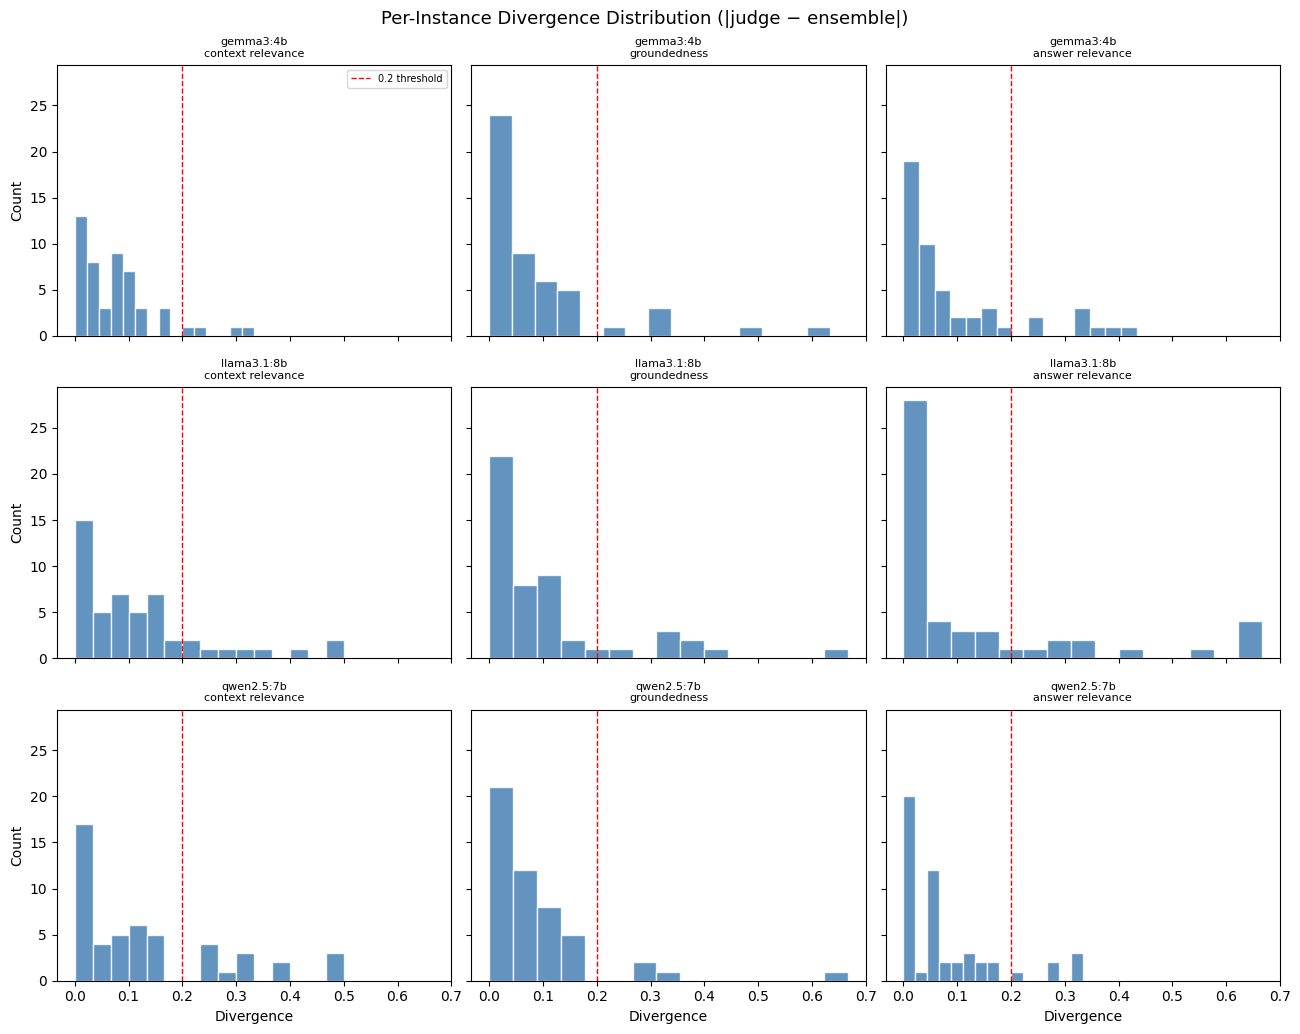

In [5]:
# Divergence distribution — model × metric histograms
if not div_df.empty:
    available_models = [m for m in MODELS if m in div_df["model"].unique()]
    n_models  = len(available_models)
    n_metrics = len(METRICS)

    fig, axes = plt.subplots(
        n_models, n_metrics, figsize=(13, 3.5 * n_models), sharex=True, sharey=True)
    if n_models == 1:
        axes = axes[np.newaxis, :]

    for row_idx, model in enumerate(available_models):
        for col_idx, metric in enumerate(METRICS):
            ax = axes[row_idx][col_idx]
            subset = div_df[
                (div_df["model"] == model) & (div_df["metric"] == metric)
            ]["divergence"]
            ax.hist(subset, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
            ax.axvline(0.2, color="red", linestyle="--", linewidth=1, label="0.2 threshold")
            ax.set_title(f"{model}\n{metric.replace('_', ' ')}", fontsize=8)
            ax.set_xlabel("Divergence" if row_idx == n_models - 1 else "")
            ax.set_ylabel("Count" if col_idx == 0 else "")
            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=7)

    fig.suptitle("Per-Instance Divergence Distribution (|judge − ensemble|)", fontsize=13)
    fig.savefig(FIGURES_DIR / "04_divergence_histograms.png", dpi=150, bbox_inches="tight")
    plt.tight_layout()
    plt.show()
else:
    print("No divergence data to plot.")


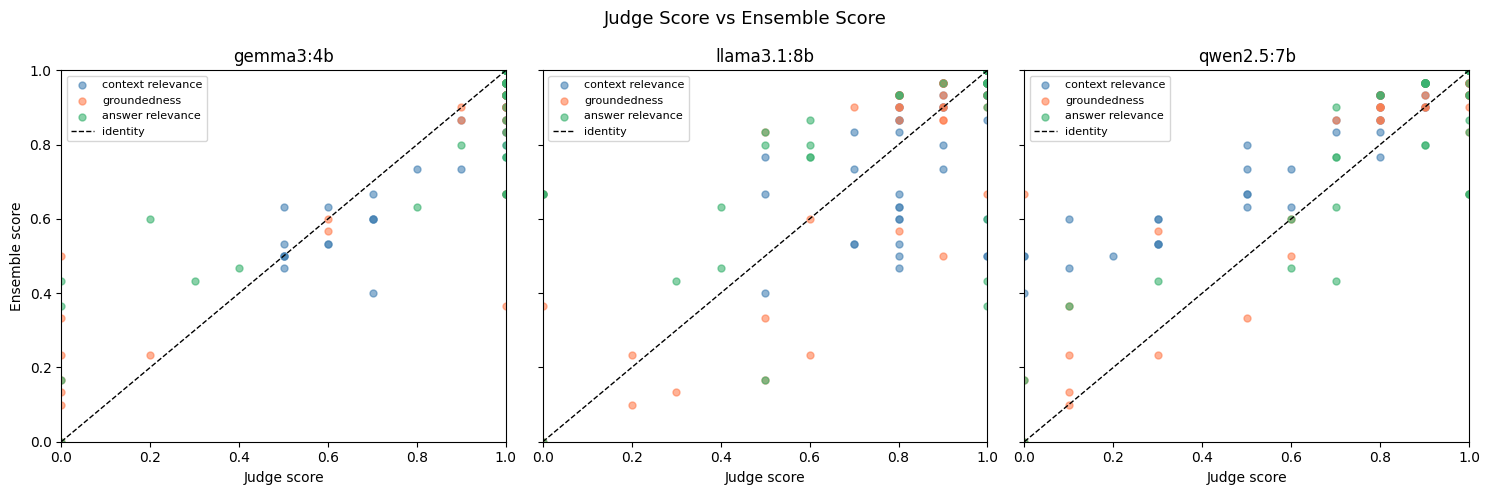

In [6]:
# Scatter: judge score vs ensemble score
if "ensemble" in scores:
    available_models = [m for m in MODELS if m in scores]
    metric_colors = {
        "context_relevance": "steelblue",
        "groundedness": "coral",
        "answer_relevance": "mediumseagreen",
    }

    fig, axes = plt.subplots(
        1, len(available_models), figsize=(5 * len(available_models), 5), sharey=True)
    if len(available_models) == 1:
        axes = [axes]

    for ax, model in zip(axes, available_models):
        for metric in METRICS:
            if metric not in scores[model] or metric not in scores["ensemble"]:
                continue
            j = scores[model][metric]
            e = scores["ensemble"][metric]
            min_len = min(len(j), len(e))
            ax.scatter(j[:min_len], e[:min_len], s=25, alpha=0.6,
                       color=metric_colors[metric], label=metric.replace("_", " "))
        ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="identity")
        ax.set_xlabel("Judge score")
        ax.set_ylabel("Ensemble score" if ax == axes[0] else "")
        ax.set_title(model)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)

    fig.suptitle("Judge Score vs Ensemble Score", fontsize=13)
    fig.savefig(FIGURES_DIR / "04_judge_vs_ensemble_scatter.png", dpi=150, bbox_inches="tight")
    plt.tight_layout()
    plt.show()
else:
    print("No ensemble scores available for scatter plot.")


In [7]:
# Absence-reasoning analysis
if not answers_df.empty and "question_type" in answers_df.columns:
    absence_ids = set(answers_df[answers_df["question_type"] == "absence_reasoning"]["id"].astype(str))
    print(f"Found {len(absence_ids)} absence-reasoning instances: {sorted(absence_ids)[:10]}")

    if absence_ids and not div_df.empty:
        absence_div = div_df[div_df["id"].astype(str).isin(absence_ids)]

        print("\nMean judge vs ensemble — absence_reasoning instances:")
        print(f"  {'model':20s}  {'metric':25s}  {'mean_judge':>10s}  {'mean_ens':>10s}  {'mean_div':>10s}")
        print("-" * 85)
        for model in [m for m in MODELS if m in div_df["model"].unique()]:
            for metric in METRICS:
                sub = absence_div[
                    (absence_div["model"] == model) & (absence_div["metric"] == metric)]
                if sub.empty:
                    continue
                mj = sub["judge_score"].mean()
                me = sub["ensemble_score"].mean()
                md = sub["divergence"].mean()
                print(f"  {model:20s}  {metric:25s}  {mj:10.4f}  {me:10.4f}  {md:10.4f}")
    else:
        print("  No absence-reasoning instances found in divergence data.")
else:
    print("No answer corpus with question_type available — skipping absence-reasoning analysis.")


Found 13 absence-reasoning instances: ['hc03_bad', 'hc03_good', 'hc03_mediocre', 'q03_graph', 'q03_vector', 'q07_graph', 'q07_vector', 'q14_graph', 'q14_vector', 'q17_graph']

Mean judge vs ensemble — absence_reasoning instances:
  model                 metric                     mean_judge    mean_ens    mean_div
-------------------------------------------------------------------------------------
  gemma3:4b             context_relevance              0.6154      0.5615      0.0795
  gemma3:4b             groundedness                   0.5000      0.5231      0.2026
  gemma3:4b             answer_relevance               0.6308      0.6590      0.2026
  llama3.1:8b           context_relevance              0.8000      0.5615      0.2385
  llama3.1:8b           groundedness                   0.6615      0.5231      0.1949
  llama3.1:8b           answer_relevance               0.6769      0.6590      0.3103
  qwen2.5:7b            context_relevance              0.2692      0.5615      0.2

In [8]:
# Consensus divergence summary report
if not div_df.empty:
    mean_div_by_model = div_df.groupby("model")["divergence"].mean()
    worst_model = mean_div_by_model.idxmax()

    mean_div_by_metric = div_df.groupby("metric")["divergence"].mean()
    worst_metric = mean_div_by_metric.idxmax()

    signed_div = div_df["judge_score"] - div_df["ensemble_score"]
    inflation_rate = (signed_div > 0).mean() * 100
    large_disagreement_rate = (div_df["divergence"] > 0.2).mean() * 100

    print("=" * 60)
    print("CONSENSUS DIVERGENCE SUMMARY")
    print("=" * 60)
    print(f"  Model with highest mean divergence : {worst_model}")
    print(f"    Mean divergence: {mean_div_by_model[worst_model]:.4f}")
    print()
    print(f"  Metric with highest mean divergence: {worst_metric}")
    print(f"    Mean divergence: {mean_div_by_metric[worst_metric]:.4f}")
    print()
    print(f"  Score inflation rate (judge > ensemble): {inflation_rate:.1f}%")
    print(f"  Large disagreement rate (div > 0.2)    : {large_disagreement_rate:.1f}%")
    print()
    print("  Mean divergence by model:")
    for model, div in mean_div_by_model.sort_values(ascending=False).items():
        print(f"    {model:20s}: {div:.4f}")
    print()
    print("  Mean divergence by metric:")
    for metric, div in mean_div_by_metric.sort_values(ascending=False).items():
        print(f"    {metric:25s}: {div:.4f}")
    print("=" * 60)
else:
    print("No divergence data available — run after scoring all answers.")

if not div_df.empty:
    available_models_local = [m for m in MODELS if m in div_df["model"].unique()]
    failure_summary = {"models": {}}
    for model in available_models_local:
        model_rows = div_df[div_df["model"] == model]
        if not model_rows.empty:
            failure_summary["models"][model] = {
                "mean_divergence": round(float(model_rows["divergence"].mean()), 4),
                "inflation_rate": round(
                    float((model_rows["judge_score"] > model_rows["ensemble_score"]).mean()), 4),
                "large_disagreement_rate": round(
                    float((model_rows["divergence"] > 0.2).mean()), 4),
            }
    failure_path = RESULTS_DIR / "04_failure_summary.json"
    failure_path.write_text(json.dumps(failure_summary, indent=2))
    print(f"Saved failure summary to {failure_path}")


CONSENSUS DIVERGENCE SUMMARY
  Model with highest mean divergence : llama3.1:8b
    Mean divergence: 0.1200

  Metric with highest mean divergence: context_relevance
    Mean divergence: 0.1093

  Score inflation rate (judge > ensemble): 40.0%
  Large disagreement rate (div > 0.2)    : 15.8%

  Mean divergence by model:
    llama3.1:8b         : 0.1200
    qwen2.5:7b          : 0.0993
    gemma3:4b           : 0.0860

  Mean divergence by metric:
    context_relevance        : 0.1093
    answer_relevance         : 0.1004
    groundedness             : 0.0956
Saved failure summary to /workspaces/llm_judge_benchmark/outputs/results/04_failure_summary.json


Proceed to notebook **05** for ensemble calibration and correction.
